# BAB 8 — TREE-BASED ALGORITHMS AND ENSEMBLE METHODS

## 8.1 Pengenalan Tree-Based Algorithms

Tree-Based Algorithm menggunakan struktur seperti pohon untuk mengambil keputusan berdasarkan fitur.

Konsep sederhananya:

Data
↓
Pertanyaan / kondisi
↓
Cabang
↓
Pertanyaan berikutnya
↓
Prediksi

Algoritma yang akan dipelajari:
- Decision Tree
- Random Forest
- Gradient Boosting
- AdaBoost
- Bagging

## 8.2 Decision Tree Classification

Decision Tree membuat keputusan berdasarkan kondisi pada fitur.

Contohnya:

Apakah umur > 20?
↓
Ya → lanjut ke pertanyaan berikutnya
Tidak → kelas tertentu

Decision Tree dapat digunakan untuk klasifikasi maupun regresi.

In [1]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

iris = load_iris()

X = iris.data
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

tree = DecisionTreeClassifier(
    random_state=42
)

tree.fit(X_train, y_train)

print(
    "Akurasi:",
    tree.score(X_test, y_test)
)

Akurasi: 0.9333333333333333


## 8.3 Visualisasi Decision Tree

Decision Tree dapat divisualisasikan untuk melihat bagaimana model membuat keputusan.

Visualisasi ini dapat membantu memahami aturan yang digunakan model.

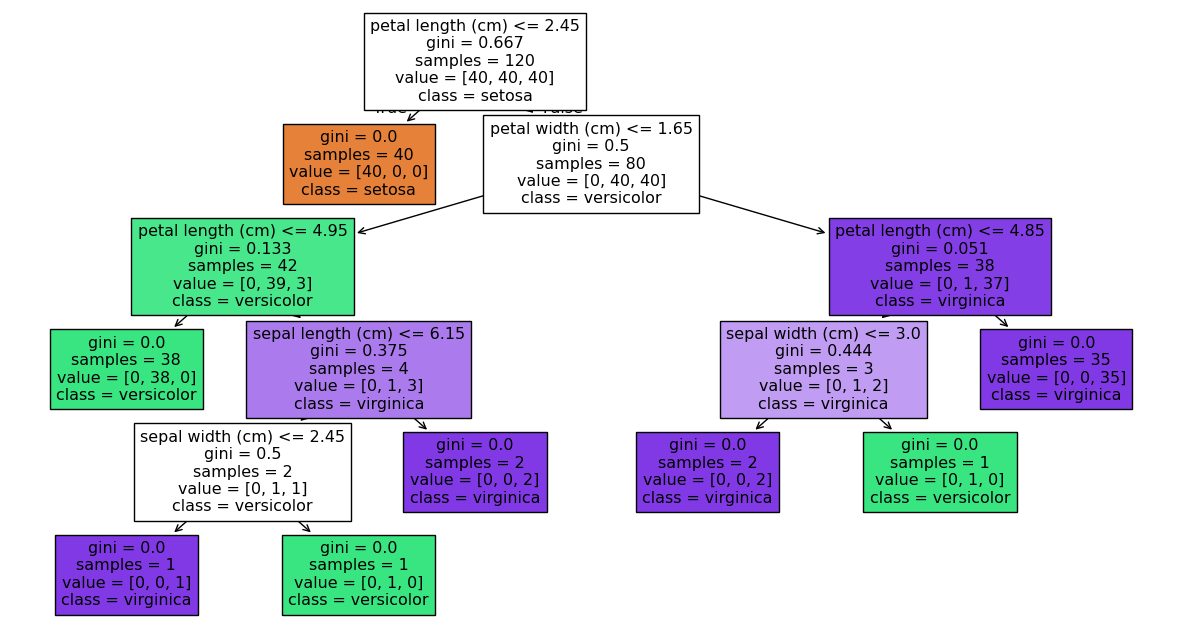

In [2]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 8))

plot_tree(
    tree,
    filled=True,
    feature_names=iris.feature_names,
    class_names=iris.target_names
)

plt.show()

## 8.4 Mengontrol Kedalaman Tree

Decision Tree dapat menjadi terlalu kompleks jika dibiarkan tumbuh terlalu dalam.

Salah satu cara mengontrol kompleksitas adalah menggunakan max_depth.

max_depth
→ Menentukan kedalaman maksimum pohon.

Tree terlalu dalam
→ Dapat menyebabkan overfitting.

Tree terlalu pendek
→ Dapat menyebabkan underfitting.

In [3]:
for depth in [1, 2, 3, 4, 5]:

    tree = DecisionTreeClassifier(
        max_depth=depth,
        random_state=42
    )

    tree.fit(X_train, y_train)

    accuracy = tree.score(
        X_test,
        y_test
    )

    print(
        "Depth =", depth,
        "| Akurasi =", accuracy
    )

Depth = 1 | Akurasi = 0.6666666666666666
Depth = 2 | Akurasi = 0.9333333333333333
Depth = 3 | Akurasi = 0.9666666666666667
Depth = 4 | Akurasi = 0.9333333333333333
Depth = 5 | Akurasi = 0.9333333333333333


## 8.5 Random Forest

Random Forest adalah ensemble yang terdiri dari banyak Decision Tree.

Setiap tree membuat prediksi, kemudian hasil dari banyak tree digabungkan.

Pada klasifikasi, hasil akhir biasanya ditentukan berdasarkan voting.

Konsep sederhananya:

Data
↓
Tree 1 → Kelas A
Tree 2 → Kelas A
Tree 3 → Kelas B
Tree 4 → Kelas A
↓
Mayoritas → Kelas A

In [4]:
from sklearn.ensemble import RandomForestClassifier

forest = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

forest.fit(X_train, y_train)

print(
    "Akurasi:",
    forest.score(X_test, y_test)
)

Akurasi: 0.9


## 8.6 Feature Importance

Random Forest dapat memberikan informasi mengenai tingkat kepentingan setiap fitur.

Nilai feature importance menunjukkan seberapa besar kontribusi relatif suatu fitur terhadap keputusan model.

In [5]:
importance = forest.feature_importances_

for feature, value in zip(
    iris.feature_names,
    importance
):
    print(
        feature,
        "→",
        round(value, 4)
    )

sepal length (cm) → 0.1163
sepal width (cm) → 0.015
petal length (cm) → 0.4315
petal width (cm) → 0.4372


## 8.7 Gradient Boosting

Gradient Boosting merupakan metode ensemble yang membuat model secara bertahap.

Model berikutnya berusaha memperbaiki kesalahan dari model sebelumnya.

Secara sederhana:

Model 1
↓
Cari kesalahan
↓
Model 2 memperbaiki kesalahan
↓
Model 3 memperbaiki kesalahan berikutnya
↓
Gabungkan semua model

In [6]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(
    random_state=42
)

gb.fit(X_train, y_train)

print(
    "Akurasi:",
    gb.score(X_test, y_test)
)

Akurasi: 0.9666666666666667


## 8.8 AdaBoost

AdaBoost atau Adaptive Boosting merupakan metode ensemble yang menggabungkan beberapa model sederhana.

Pada setiap tahap, model memberikan perhatian lebih pada data yang sebelumnya salah diprediksi.

Dengan demikian, model berikutnya mencoba memperbaiki kesalahan model sebelumnya.

In [7]:
from sklearn.ensemble import AdaBoostClassifier

ada = AdaBoostClassifier(
    random_state=42
)

ada.fit(X_train, y_train)

print(
    "Akurasi:",
    ada.score(X_test, y_test)
)

Akurasi: 0.9333333333333333


## 8.9 Bagging

Bagging atau Bootstrap Aggregating membuat beberapa model dari sampel data yang berbeda.

Kemudian hasil prediksi dari model-model tersebut digabungkan.

Tujuan utamanya adalah mengurangi variasi model dan membuat prediksi lebih stabil.

Random Forest merupakan salah satu contoh metode ensemble berbasis bagging.

In [8]:
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier

bagging = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=100,
    random_state=42
)

bagging.fit(X_train, y_train)

print(
    "Akurasi:",
    bagging.score(X_test, y_test)
)

Akurasi: 0.9666666666666667


## 8.10 Membandingkan Model Ensemble

Kita dapat membandingkan beberapa algoritma tree-based dan ensemble pada dataset yang sama.

Model yang dibandingkan:
- Decision Tree
- Random Forest
- Gradient Boosting
- AdaBoost
- Bagging

In [9]:
models = {
    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42
    ),

    "AdaBoost": AdaBoostClassifier(
        random_state=42
    ),

    "Bagging": BaggingClassifier(
        estimator=DecisionTreeClassifier(),
        n_estimators=100,
        random_state=42
    )
}

for name, model in models.items():

    model.fit(X_train, y_train)

    accuracy = model.score(
        X_test,
        y_test
    )

    print(
        name,
        "→ Akurasi:",
        accuracy
    )

Decision Tree → Akurasi: 0.9333333333333333
Random Forest → Akurasi: 0.9
Gradient Boosting → Akurasi: 0.9666666666666667
AdaBoost → Akurasi: 0.9333333333333333
Bagging → Akurasi: 0.9666666666666667


## 8.11 Perbedaan Metode

Decision Tree
→ Satu pohon keputusan.

Random Forest
→ Banyak Decision Tree yang digabungkan menggunakan pendekatan bagging.

Gradient Boosting
→ Model dibuat secara bertahap untuk memperbaiki kesalahan model sebelumnya.

AdaBoost
→ Memberikan perhatian lebih pada data yang sebelumnya salah diprediksi.

Bagging
→ Membuat beberapa model dari sampel data yang berbeda lalu menggabungkan hasilnya.

Secara sederhana:

Decision Tree
→ 1 model pohon

Random Forest
→ Banyak pohon + bagging

Boosting
→ Model dibuat bertahap untuk memperbaiki kesalahan

## 8.12 Kesimpulan Bab 8

Decision Tree
→ Membuat keputusan berdasarkan percabangan fitur.

Random Forest
→ Menggabungkan banyak Decision Tree.

Gradient Boosting
→ Membuat model secara bertahap untuk memperbaiki kesalahan.

AdaBoost
→ Memberikan perhatian lebih pada data yang sulit diprediksi.

Bagging
→ Menggabungkan beberapa model yang dilatih pada sampel data berbeda.

Tree-Based Model memiliki beberapa kelebihan:
- Dapat menangani hubungan non-linear.
- Tidak selalu membutuhkan scaling.
- Dapat digunakan untuk klasifikasi dan regresi.
- Beberapa model dapat memberikan feature importance.

Alur sederhananya:

Data
↓
Decision Tree
↓
Ensemble
↓
Random Forest / Boosting / Bagging
↓
Prediksi